# 5-DOF system with general damping

In [1]:
def excit_force(Q0,alpha_e,t):
    '''
    Function to calculate the excitation force vector Q(t)
    for the case of a half-sin pulse with complex amplitude
    vector Q0 and circular frequency alpha_e.
    '''
    from numpy import exp, pi
    T = 2*pi/alpha_e
    if t < T/2:
        Q = -1j*Q0/2*exp(1j*alpha_e*t) + 1j*Q0.conjugate()/2*exp(-1j*alpha_e*t)
        if max(abs(Q.imag)) > max(abs(Q0))/1.0e13:
            print('Warning: non-zero imaginary part in excitation force.')
            
        Q = Q.real
    else:
        Q = Q0*0.0
    
    return Q

def xdot(t,x,A,B,Q0,alpha_e):
    '''
    Function to calculate the first time derivative of the state vector x
    due to the excitation force Q
    '''
    Q = excit_force(Q0,alpha_e,t)
    return A@x + B@Q

In [2]:

from numpy import (array, pi, sin, cos, linspace, array, exp, sqrt,
         rad2deg, angle, diag, sort, dot, zeros, eye, ones,
         hstack, vstack, empty, arange, squeeze, savez, load)
from scipy.integrate import solve_ivp
from numpy.linalg import eig, inv, det, norm
from pandas import read_excel
from printarray import printarray
from matplotlib.pyplot import (plot, semilogy, grid, xlabel, ylabel,
      figure, legend, axis, title, show)


In [3]:
KDF = read_excel('/Users/terry/2025-2026-winter/Vibration/Lab_5_2025_data_files/stiffness_matrix.xlsx')
MDF = read_excel('/Users/terry/2025-2026-winter/Vibration/Lab_5_2025_data_files/mass_matrix.xlsx')
CDF = read_excel('/Users/terry/2025-2026-winter/Vibration/Lab_5_2025_data_files/damping_matrix.xlsx')

Q0_DF = read_excel('/Users/terry/2025-2026-winter/Vibration/Lab_5_2025_data_files/Excitation_force_amplt.xlsx')

In [4]:
K = KDF.values
M = MDF.values
C = CDF.values

Q0_excit = squeeze(Q0_DF.values)

printarray(Q0_excit,'.4f',name = 'Q0_ampl',eu = 'N')
msiz = K.shape[0]

Q0_ampl  = [64.4055 73.0005 107.2847 123.3073 97.4066 ]  N


Meirovitch equation (7.234) p. 346:

$$ A = \left[ \begin{array}{cc} 0 & I \\[3mm]
-M^{-1} K & -M^{-1} C \end{array} \right] \rule{10mm}{0mm}
B = \left[ \begin{array}{c} 0 \\[3mm]
M^{-1} \end{array} \right] $$


In [5]:
dum = inv(M)
AA  = hstack((zeros((msiz,msiz)),eye(msiz)))
AA  = vstack((AA,hstack((-dum@K,-dum@C))))
BB  = vstack((zeros((msiz,msiz)),dum))
              
print('\nAA:')
for ii in range(msiz*2):
    printarray(AA[ii,:],'.4f')
        
print('\nBB:')
for ii in range(msiz*2):
    printarray(BB[ii,:],'.4f')


AA:
[0.0000 0.0000 0.0000 0.0000 0.0000 1.0000 0.0000 0.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 1.0000 0.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 1.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 1.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 1.0000 ]
[-5058.6712 -5008.1483 1184.7213 -245.6541 1285.8345 -2.0311 0.1705 -0.3514 0.6206 -0.3690 ]
[-3479.0937 -5142.4877 17.2116 344.6358 891.4770 -0.0786 -1.1796 0.7336 -0.6113 -0.2337 ]
[-1329.8380 -2084.6572 -919.7187 664.4591 102.1398 0.0212 0.9039 -1.6035 -0.0252 0.2804 ]
[26.4188 238.1713 1281.7076 -1171.6469 711.4888 0.3586 -0.5451 -0.0091 -0.7623 0.0715 ]
[3364.0760 4298.7788 -829.1297 548.1839 -1482.2311 -0.0243 -1.1073 1.3249 -0.0677 -0.7229 ]

BB:
[0.0000 0.0000 0.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.0000 0.0000 0.0000 ]
[0.0000 0.0000 0.000

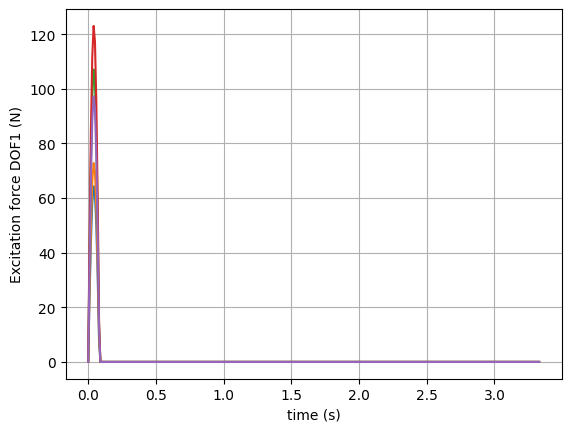

In [6]:
f_exit = 6.0   # frequency in Hz of half-sine pulse
T      = 1/f_exit

alpha_excit = 2*pi*f_exit

t_span = [0.0,20.0*T]
# t_span = [0.0,100.0*T]
delt   = 0.01
t_eval = arange(t_span[0],t_span[1],delt)
# t_eval = linspace(t_span[0],t_span[1],400)

Q0_val = array([[]])
for ii in range(msiz-1):
    Q0_val = vstack((Q0_val,array([[]])))

Q0_val = Q0_val.T

for t in t_eval:
    Q0_val = vstack((Q0_val,excit_force(Q0_excit,alpha_excit,t)))

q_init =  zeros(2*msiz)

#matplotlib qt5

figure(1)
plot(t_eval,Q0_val)
ylabel('Excitation force DOF1 (N)')
xlabel('time (s)')
grid(True)
show()

In [7]:
Q0_val

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [23.70925408, 26.87329022, 39.49412112, 45.3924585 , 35.85776401],
       [44.08861388, 49.97230669, 73.4414103 , 84.40968109, 66.67941162],
       ...,
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]],
      shape=(334, 5))

In [8]:
sol = solve_ivp(xdot,t_span,q_init,t_eval=t_eval,args=(AA,BB,Q0_excit,alpha_excit))
# sol = solve_ivp(xdot,t_span,q_init,args=(AA,BB,Q0_excit,alpha_excit))
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-02 ...  3.320e+00  3.330e+00]
        y: [[ 0.000e+00  4.743e-05 ... -3.276e-03 -3.148e-03]
            [ 0.000e+00  4.539e-05 ... -4.509e-03 -4.349e-03]
            ...
            [ 0.000e+00  2.630e-02 ...  1.258e-01  1.407e-01]
            [ 0.000e+00  1.538e-02 ...  1.120e-01  1.304e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1934
     njev: 0
      nlu: 0


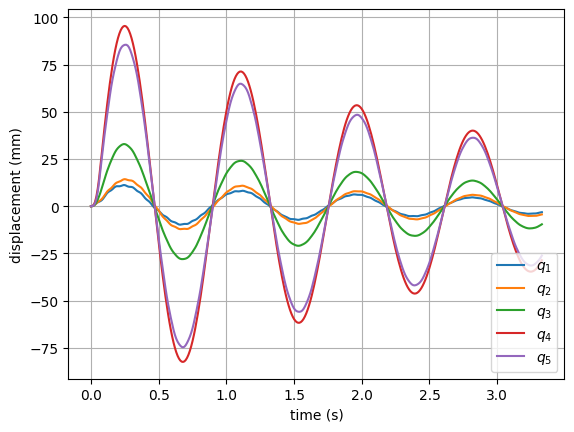

In [9]:
figure(2)
plot(sol.t,sol.y[0,:]*1000, label = r'$q_1$')
plot(sol.t,sol.y[1,:]*1000, label = r'$q_2$')
plot(sol.t,sol.y[2,:]*1000, label = r'$q_3$')
plot(sol.t,sol.y[3,:]*1000, label = r'$q_4$')
plot(sol.t,sol.y[4,:]*1000, label = r'$q_5$')

grid(True)
xlabel('time (s)')
ylabel('displacement (mm)')
legend(loc='lower right')
show()

In [10]:
filen = 'lab5_ODE_results'
tt  = sol.t
yy  = sol.y
savez(filen,tt=tt, yy=yy, t_eval=t_eval, Q0_val=Q0_val)

In [11]:
with load('lab5_Newmark_results.npz') as npzfile:
    npzfile.allow_pickle = True

    for arii in npzfile.files:
        if arii == 't_eval':
            t_eval = npzfile[arii]
        if arii == 'qh':
            qh = npzfile[arii]
        if arii == 'Q0_val':
            Q0_val = npzfile[arii]

FileNotFoundError: [Errno 2] No such file or directory: 'lab5_Newmark_results.npz'

NameError: name 'qh' is not defined

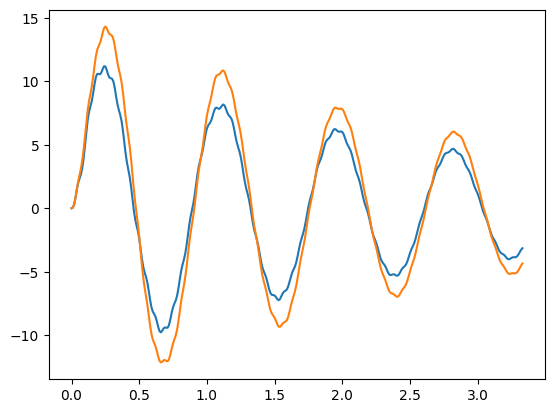

In [12]:
figure(3)
plot(sol.t,sol.y[0,:]*1000, label = 'Runge-Kutta q1')
plot(sol.t,sol.y[1,:]*1000, label = 'Runge-Kutta q2')
plot(t_eval,qh[:,0]*1000,label = 'Newmark q1')
plot(t_eval,qh[:,1]*1000,label = 'Newmark q2')
grid(True)
xlabel('time (s)')
ylabel('displacement (mm)')
legend(loc='lower right')
show()

NameError: name 'qh' is not defined

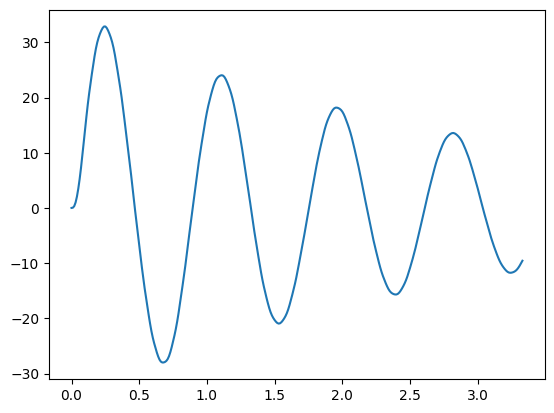

In [13]:
figure(4)
plot(sol.t,sol.y[2,:]*1000, label = 'Runge-Kutta q3')
plot(t_eval,qh[:,2]*1000,label = 'Newmark q3')
grid(True)
xlabel('time (s)')
ylabel('displacement (mm)')
legend(loc='lower right')
show()

NameError: name 'qh' is not defined

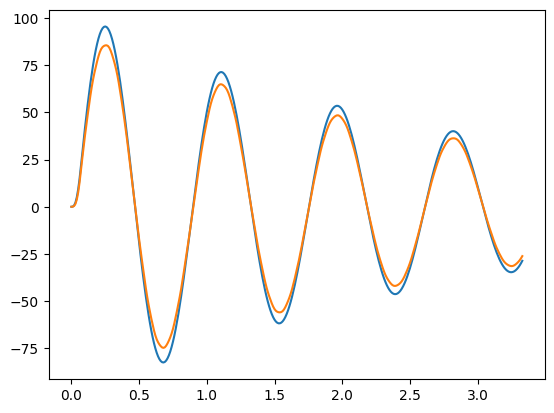

In [14]:
figure(5)
plot(sol.t,sol.y[3,:]*1000, label = 'Runge-Kutta q4')
plot(sol.t,sol.y[4,:]*1000, label = 'Runge-Kutta q5')
plot(t_eval,qh[:,3]*1000,label = 'Newmark q4')
plot(t_eval,qh[:,4]*1000,label = 'Newmark q5')
grid(True)
xlabel('time (s)')
ylabel('displacement (mm)')
legend(loc='lower right')
show()